In [26]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [27]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

## For Numeric Data

In [28]:
df = pd.read_csv('/content/train.csv',usecols = ['Age','Fare','Survived'])

In [29]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


In [31]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [32]:
x = df.drop(columns ='Survived')
y = df['Survived']


In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)


In [34]:
x_train['age_imputed'] = x_train['Age']
x_test['age_imputed'] = x_test['Age']

In [43]:
x_train['age_imputed'][x_train['age_imputed'].isnull()] = x_train['Age'].dropna().sample(x_train['Age'].isnull().sum()).values
x_test['age_imputed'][x_test['age_imputed'].isnull()] = x_test['Age'].dropna().sample(x_test['Age'].isnull().sum()).values

In [46]:
x_train.sample(10)

,Age,Fare,age_imputed
738,NaN,7.8958,28.0
427,19.0,26.0000,19.0
407,3.0,18.7500,3.0
615,24.0,65.0000,24.0
553,22.0,7.2250,22.0
468,NaN,7.7250,24.0
71,16.0,46.9000,16.0
149,42.0,13.0000,42.0
642,2.0,27.9000,2.0
61,38.0,80.0000,38.0


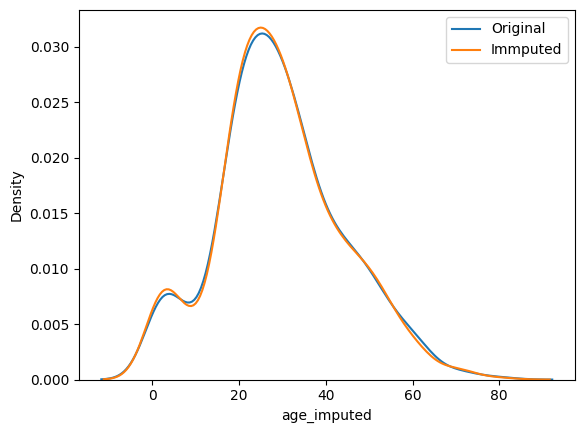

In [51]:
sns.distplot(x_train['Age'],label = 'Original',hist=False)
sns.distplot(x_train['age_imputed'],label = 'Immputed',hist = False)
plt.legend()

In [53]:
print('original Dataset',x_train['Age'].var())
print('After Impuation Dataset',x_train['age_imputed'].var())

original Dataset 210.2517072477438
After Impuation Dataset 208.89090393021388


In [57]:
x_train[['Age','Fare','age_imputed']].cov()

,Age,Fare,age_imputed
Age,210.251707,71.580633,210.251707
Fare,71.580633,2700.831981,47.443172
age_imputed,210.251707,47.443172,208.890904


<Axes: >

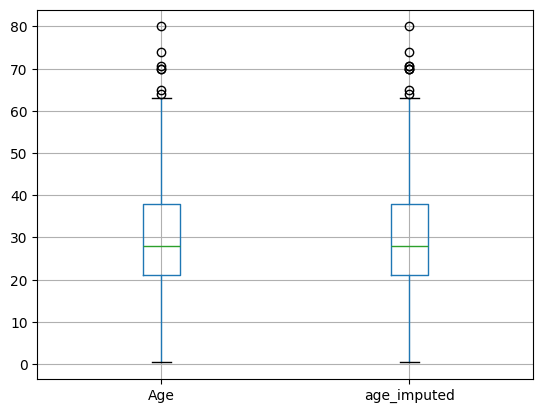

In [59]:
x_train[['Age','age_imputed']].boxplot()

In [64]:
# When Make production base model get one random age at one specific Fare
sample_value = x_train['Age'].dropna().sample(1, random_state=42)

## For Categorical Data

In [69]:
data = pd.read_csv('/content/Train_edited.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [72]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [74]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [76]:
x = data
y = data['SalePrice']

In [79]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [81]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [83]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [85]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [91]:
temp = pd.concat([
    X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts() / len(X_train),

],axis = 1)
temp.columns = ['Original','Imputed']

In [92]:
temp

,Original,Imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [93]:
temp = pd.concat([
    X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts() / len(X_train),

],axis = 1)
temp.columns = ['Original','Imputed']

In [95]:
temp

,Original,Imputed
Gd,0.494272,0.498288
TA,0.412439,0.410103
Fa,0.040917,0.041096
Po,0.027823,0.027397
Ex,0.024550,0.023116


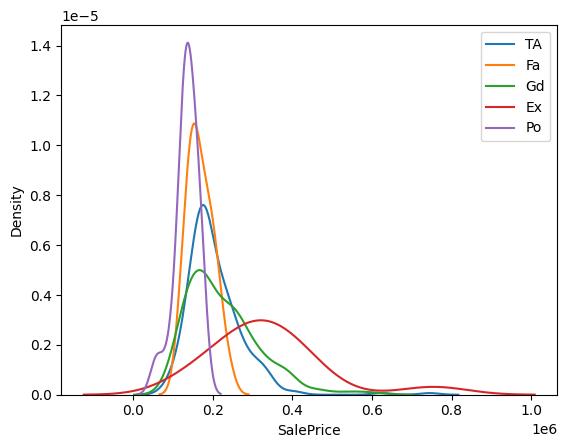

In [98]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist = False,label = category)
plt.legend()

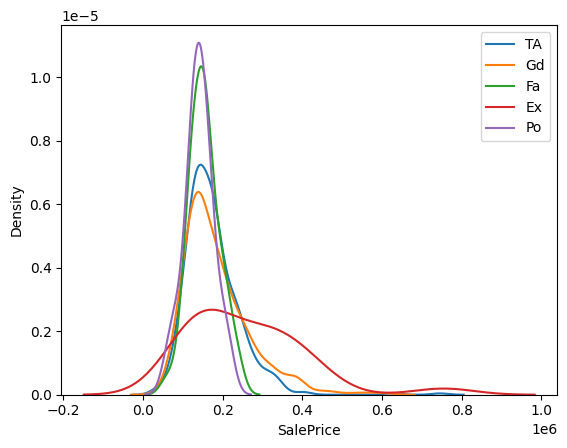

In [99]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist = False,label = category)
plt.legend()